In [74]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df = pd.read_csv("./Advertising.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [7]:
# we can take x = df.drop("Selling_Price",axis =1)
x = df[["TV", "Radio","Newspaper"]]
y = df["Sales"]

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=32,test_size=0.3)

In [9]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [10]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [ 0.04589471  0.19358946 -0.00610337]
Intercept 3.0759079537672402


In [11]:
print("MAE", metrics.mean_absolute_error(y_test,y_pred))
print("MSE", metrics.mean_squared_error(y_test,y_pred))
print("R2 Score", metrics.r2_score(y_test,y_pred))

MAE 1.3654567890610605
MSE 3.7495203698290345
R2 Score 0.8320470849488278


In [12]:
diff = pd.DataFrame({"Actual":y_test,"Predict":y_pred})
diff

,Actual,Predict
122,11.6,13.725726
186,10.3,9.722409
167,12.2,13.455194
101,23.8,23.090568
29,10.5,9.164489
75,8.7,11.765747
144,11.4,10.118682
28,18.9,19.601020
121,7.0,7.832010
182,8.7,6.577381


In [29]:
df = pd.read_csv("./FuelConsumptionCo2.csv")
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   str    
 2   MODEL                     1067 non-null   str    
 3   VEHICLECLASS              1067 non-null   str    
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   str    
 7   FUELTYPE                  1067 non-null   str    
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 108.5 KB


In [31]:
df.isna().sum()

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

In [32]:
df.drop(columns=["MAKE","MODEL"	,"VEHICLECLASS"	,"TRANSMISSION"], inplace=True)

In [33]:
df["age"] = 2026 - df[["MODELYEAR"]]
df


,MODELYEAR,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,age
0,2014,2.0,4,Z,9.9,6.7,8.5,33,196,12
1,2014,2.4,4,Z,11.2,7.7,9.6,29,221,12
2,2014,1.5,4,Z,6.0,5.8,5.9,48,136,12
3,2014,3.5,6,Z,12.7,9.1,11.1,25,255,12
4,2014,3.5,6,Z,12.1,8.7,10.6,27,244,12
...,...,...,...,...,...,...,...,...,...,...
1062,2014,3.0,6,X,13.4,9.8,11.8,24,271,12
1063,2014,3.2,6,X,13.2,9.5,11.5,25,264,12
1064,2014,3.0,6,X,13.4,9.8,11.8,24,271,12
1065,2014,3.2,6,X,12.9,9.3,11.3,25,260,12


In [34]:
df.corr(numeric_only=True)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,age
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154,NaN
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685,NaN
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039,NaN
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748,NaN
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129,NaN
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394,NaN
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000,NaN
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# we can take x = df.drop("Selling_Price",axis =1)
x = df[["ENGINESIZE","FUELCONSUMPTION_COMB","CYLINDERS"]]
y = df["CO2EMISSIONS"]

In [56]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=100,test_size=0.3)

In [57]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [58]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [11.14798722  9.73505283  7.09354891]
Intercept 65.3941724081501


In [59]:
print("MAE", metrics.mean_absolute_error(y_test,y_pred))
print("MSE", metrics.mean_squared_error(y_test,y_pred))
print("R2 Score", metrics.r2_score(y_test,y_pred))

MAE 16.238304829225847
MSE 514.249783544342
R2 Score 0.8605707371421957


In [60]:
diff = pd.DataFrame({"Actual":y_test,"Predict":y_pred})
diff

,Actual,Predict
849,271,261.847045
244,299,307.782583
30,258,250.432019
306,308,316.135799
240,270,345.749289
...,...,...
483,200,205.218497
966,297,278.129596
894,299,302.208589
23,230,213.414871


In [66]:
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.mean_absolute_error(y_test,y_pred)
minimum = min(m.values())
k = [i for i,j in m.items() if j ==minimum]
print(k,minimum)

[7] 14.854995454030016


## Polynomial linear regression


In [68]:
df = pd.read_csv("../../../../PYTHON-2-DATASET-main/polylinearregression.csv")
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [107]:
x = df[["Temperature"]]
y = df["Pressure"]

In [106]:
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.r2_score(y_test,y_pred)

k = [i for i,j in m.items() if j == max(m.values())]
print(k,max(m.values()))

[25] 0.20034223522242245


In [108]:
lr = LinearRegression()
lr.fit(x,y)
y_pred = lr.predict(x)

In [101]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [0.001452]
Intercept -0.0408


In [109]:
print("R2 Score", metrics.r2_score(y,y_pred))

R2 Score 0.690349972603981


In [120]:
poly = PolynomialFeatures(degree=5)
x_poly = poly.fit_transform(x)
x_poly

array([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.0000e+00, 2.0000e+01, 4.0000e+02, 8.0000e+03, 1.6000e+05,
        3.2000e+06],
       [1.0000e+00, 4.0000e+01, 1.6000e+03, 6.4000e+04, 2.5600e+06,
        1.0240e+08],
       [1.0000e+00, 6.0000e+01, 3.6000e+03, 2.1600e+05, 1.2960e+07,
        7.7760e+08],
       [1.0000e+00, 8.0000e+01, 6.4000e+03, 5.1200e+05, 4.0960e+07,
        3.2768e+09],
       [1.0000e+00, 1.0000e+02, 1.0000e+04, 1.0000e+06, 1.0000e+08,
        1.0000e+10]])

In [121]:
lr.fit(x_poly,y)
y_pred = lr.predict(x_poly)
y_pred

array([2.00000314e-04, 1.20000006e-03, 5.99999994e-03, 2.99999999e-02,
       8.99999998e-02, 2.70000000e-01])

In [122]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [ 0.00000000e+00  8.52166654e-04 -8.14375002e-05  2.67604168e-06
 -3.39062502e-08  1.71354168e-10]
Intercept 0.0002000003141488238


In [123]:
print("R2 Score", metrics.r2_score(y,y_pred))

R2 Score 1.0


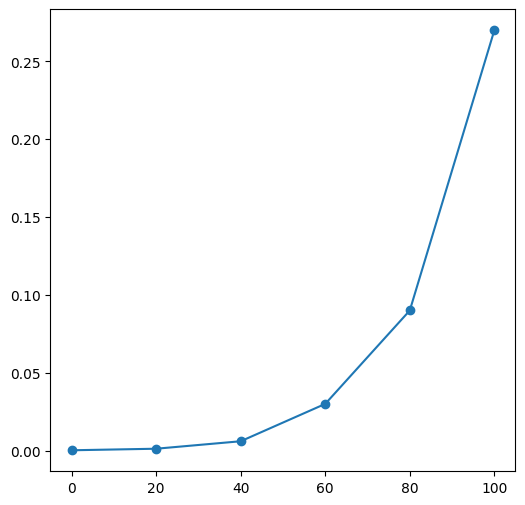

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(x,y)
plt.plot(x,y_pred)

In [141]:
df = pd.read_csv("../../../../PYTHON-2-DATASET-main/car_data.csv")
df

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14
5,220,4354,12
6,95,2372,25
7,88,2130,27
8,98,2228,24


In [142]:
x = df[["Horsepower","Weight"]]
y = df["MPG"]

In [143]:
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.r2_score(y_test,y_pred)

k = [i for i,j in m.items() if j == max(m.values())]
print(k,max(m.values()))

[8] 0.9711995921331791


In [144]:
lr = LinearRegression()
lr.fit(x,y)
y_pred = lr.predict(x)

In [145]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [-0.00510729 -0.00580665]
Intercept 38.53353251084853


In [146]:
print("R2 Score", metrics.r2_score(y,y_pred))

R2 Score 0.9485920469558486


In [163]:
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)
x_poly


array([[1.0000000e+00, 1.3000000e+02, 3.5040000e+03, 1.6900000e+04,
        4.5552000e+05, 1.2278016e+07],
       [1.0000000e+00, 1.6500000e+02, 3.6930000e+03, 2.7225000e+04,
        6.0934500e+05, 1.3638249e+07],
       [1.0000000e+00, 1.5000000e+02, 3.4360000e+03, 2.2500000e+04,
        5.1540000e+05, 1.1806096e+07],
       [1.0000000e+00, 1.4000000e+02, 3.4330000e+03, 1.9600000e+04,
        4.8062000e+05, 1.1785489e+07],
       [1.0000000e+00, 1.9800000e+02, 4.3410000e+03, 3.9204000e+04,
        8.5951800e+05, 1.8844281e+07],
       [1.0000000e+00, 2.2000000e+02, 4.3540000e+03, 4.8400000e+04,
        9.5788000e+05, 1.8957316e+07],
       [1.0000000e+00, 9.5000000e+01, 2.3720000e+03, 9.0250000e+03,
        2.2534000e+05, 5.6263840e+06],
       [1.0000000e+00, 8.8000000e+01, 2.1300000e+03, 7.7440000e+03,
        1.8744000e+05, 4.5369000e+06],
       [1.0000000e+00, 9.8000000e+01, 2.2280000e+03, 9.6040000e+03,
        2.1834400e+05, 4.9639840e+06]])

In [168]:
x_train,x_test,y_train,y_test = train_test_split(x_poly,y,test_size=0.3, random_state=1)

In [171]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred

array([28.15877662, 15.87394942, 22.45362457])

In [172]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [ 0.00000000e+00  1.26626233e+00 -9.21938761e-02  5.10596751e-03
 -8.03332688e-04  3.01117509e-05]
Intercept 86.36393523935823


In [174]:
print("R2 Score", metrics.r2_score(y_test,y_pred))

R2 Score 0.012806676940418704
